In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os
import re
pd.set_option("display.max_rows", None)

def calculate_and_contour_bright_areas_adjusted(image, threshold_value, contour_thickness, num_contours):
    _, thresh = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    areas_and_centroids = []

    for c in contours:
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        if perimeter == 0:
            continue
        
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = w / float(h)
        if 0.3 < aspect_ratio < 2.1:
            M = cv2.moments(c)
                cx = int(M["m10"] / M["m00"])
            if M["m00"] != 0:
                cy = int(M["m01"] / M["m00"])
                areas_and_centroids.append((area, (cx, cy), c))

    largest_areas_and_centroids = sorted(areas_and_centroids, key=lambda x: x[0], reverse=True)[:num_contours]
    largest_areas_and_centroids_sorted_by_y = sorted(largest_areas_and_centroids, key=lambda x: x[1][1])

    image_with_contours = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    valid_contours = [c[2] for c in largest_areas_and_centroids_sorted_by_y]
    cv2.drawContours(image_with_contours, valid_contours, -1, (0, 255, 0), contour_thickness)

    return image_with_contours, largest_areas_and_centroids_sorted_by_y


def process_image(image_path, brightness=130, thickness=5, pixel_per_mm=610, to_plot=False):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image is None:
        return "Image not loaded"
    
    # Convert image to HSV color space
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define range for green color
    lower_green = np.array([36, 25, 25])
    upper_green = np.array([86, 255, 255])
    
    # Define range for orange color
    lower_orange = np.array([5, 10, 100])
    upper_orange = np.array([35, 255, 255])


    # Create a mask for orange color
    orange_mask = cv2.inRange(hsv_image, lower_orange, upper_orange)

    # Create a mask to isolate green pixels
    green_mask = cv2.inRange(hsv_image, lower_green, upper_green)
    green_channel = cv2.bitwise_and(image, image, mask=orange_mask)[:, :, 1]  # Isolating the green channel of the green areas

# Create a CLAHE object (with default parameters)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    green_channel_clahe = clahe.apply(green_channel)  # Apply CLAHE to the green channel

    adjusted_threshold_value = brightness
    adjusted_contour_thickness = thickness

    file_name = os.path.basename(image_path)
    split_file_name = file_name.split()

    N = sum(element.isdigit() for element in split_file_name)

    image_with_contours_adjusted, areas_and_centroids_adjusted = calculate_and_contour_bright_areas_adjusted(
        green_channel_clahe, adjusted_threshold_value, adjusted_contour_thickness, N)
    # largest_areas_and_centroids = sorted(areas_and_centroids_adjusted, key=lambda x: x[0], reverse=True)[:N]
    # largest_areas_and_centroids_sorted_by_y = sorted(largest_areas_and_centroids, key=lambda x: x[1][1])
    result = [area/pixel_per_mm**2*10**6 for area, _,__ in areas_and_centroids_adjusted]

    if to_plot:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(image_with_contours_adjusted, cv2.COLOR_BGR2RGB))
        plt.title(f"{file_name}")
        plt.axis('off')
        plt.show()

    return result


In [15]:
def process_images_in_folder(folder_path, brightness=130, thickness=5, pixel_per_mm=610, to_plot = False):
    # List all files in the given folder
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

    # Prepare a list to store results
    results = []

    # Loop through each image file
    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        pattern = r"fish ((?:\d+ ?)+).*top (\w+) wt and bottom (\w+) ko"
        match = re.search(pattern, image_file)
        if match:
            fish_numbers = list(map(int, match.group(1).split()))
            top_count = match.group(2)
            bottom_count = match.group(3)
            
            num_mapping = {'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4}
            top_num = num_mapping.get(top_count, 0)
            bottom_num = num_mapping.get(bottom_count, 0)
            
            types = ['wt'] * top_num + ['ko'] * bottom_num
            if 'bw' in image_file:
                color = 'bw'
            else:
                color = 'orange'
        # Process the image and store the result
        try:
            processed_result = process_image(image_path, brightness, thickness, pixel_per_mm, to_plot)
            for index,number in enumerate(processed_result):
                results.append({
                    # 'image': image_file,
                    'fish number': fish_numbers[index],
                    'type' : types[index],
                    'area in mcm^2': round(number),
                    'color': color
                })
                # print(fish_numbers)
        except Exception as e:
            print(f"Error processing {image_file}: {e}")

    # Convert the results into a pandas DataFrame
    df = pd.DataFrame(results)

    return df

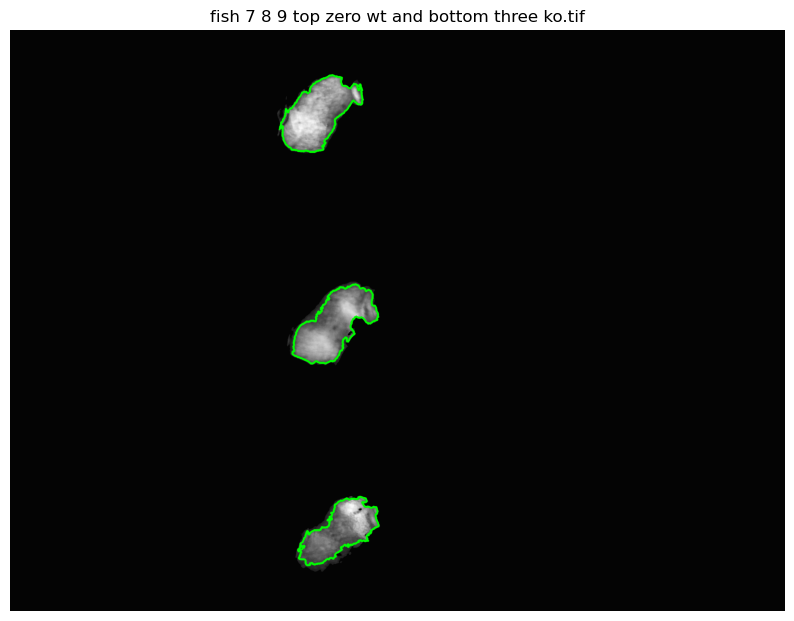

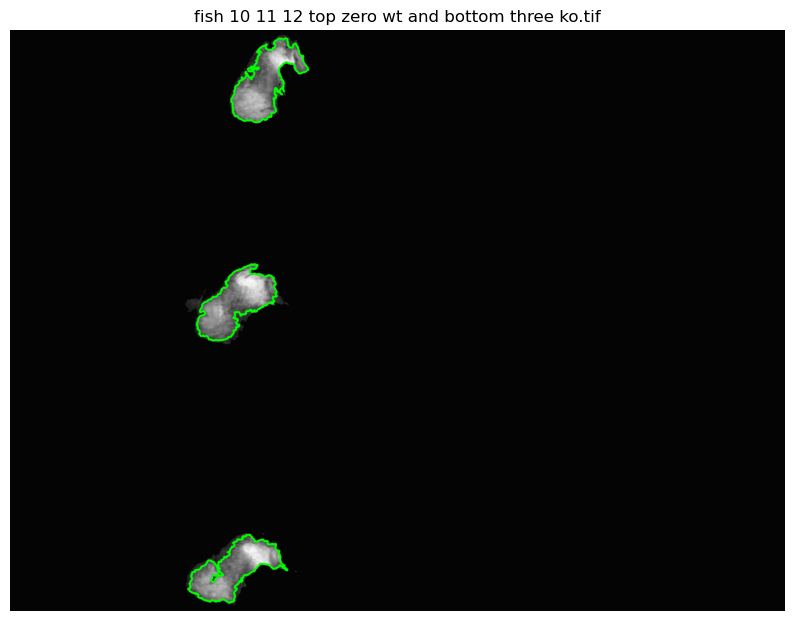

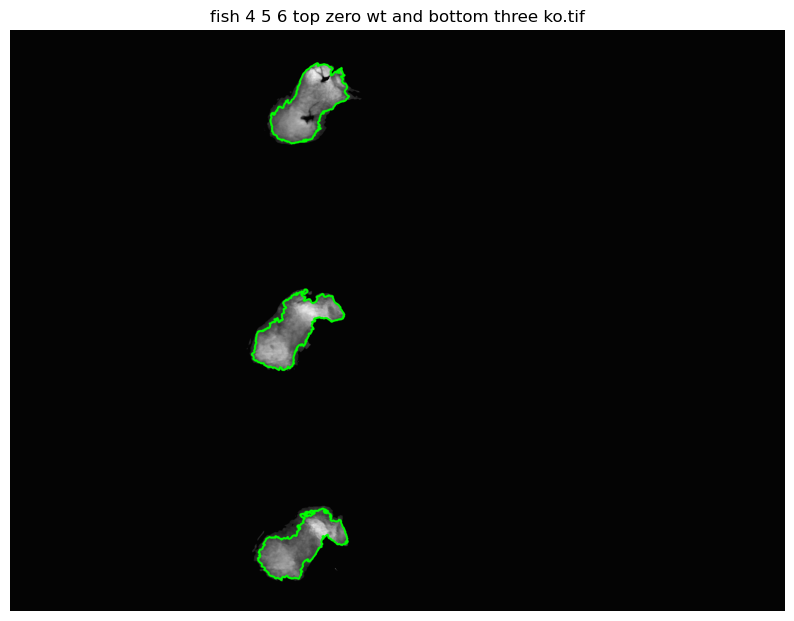

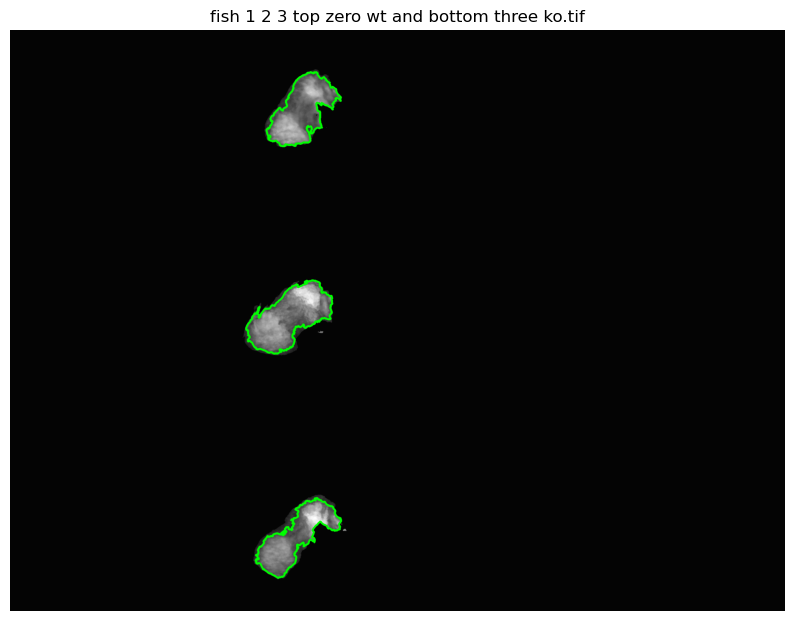

In [21]:
# folder 1 610 pixels per mm
folder_path = "microgravity 5 dpf lipens"
data = process_images_in_folder(folder_path, brightness=60, pixel_per_mm=882,to_plot=True)
# data.sort_values(by=['type',"fish number", 'color'], ascending=True, inplace=True)
# data = data[data['color'] == 'green']
# data = data.reset_index(drop = True)

# # folder 2 384 pixels per mm
# folder_path = "./5 dpf july 1st 2024"
# data = process_images_in_folder(folder_path, brightness=110, pixel_per_mm=384,to_plot=True)
# data.sort_values(by=['type',"fish number", 'color'], ascending=True, inplace=True)
# data = data[data['color'] == 'green']
# data2 = data.reset_index(drop = True)

In [22]:
# data = pd.concat([data1,data2])
# data.sort_values(by=['type',"fish number", 'color'], ascending=True, inplace=True)
# data = data[data['color'] == 'green']
# data = data.reset_index(drop = True)
data

,fish number,type,area in mcm^2,color
0,7,ko,49667,orange
1,8,ko,50542,orange
2,9,ko,39354,orange
3,10,ko,42800,orange
4,11,ko,43798,orange
5,12,ko,41649,orange
6,4,ko,47227,orange
7,5,ko,46389,orange
8,6,ko,41974,orange
9,1,ko,40496,orange


In [32]:
from scipy.stats import ttest_ind

# Creating DataFrame
df = data

# Separating the data into groups based on the type
group_ko = df[df['type'] == 'ko']['area in mcm^2']
group_wt = df[df['type'] == 'wt']['area in mcm^2']

# Performing the t-test
t_stat, p_value = ttest_ind(group_ko, group_wt, equal_var=True)

# Printing the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 1.3178745400568994
P-value: 0.20731892314732658


In [33]:
# data.to_csv('data.csv')

In [34]:
data.groupby('type')['area in mcm^2'].mean().reset_index()

,type,area in mcm^2
0,ko,28373.300000
1,wt,23407.428571
